# UX - Correlation and Regression Assignment

author:
- |
    Sofia Dahl, sof@create.aau.dk\
    Dept. Architecture, Design and Media Technology, Aalborg University Copenhagen
---



In [66]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Group 2

- Ingrid Evertsen
- Nick Lee Jerlung
- Nanna Friis Pedersen
- Diana Nina Demidova Pedersen
- Valdemar Heller Wessing

### Case example: Force data
In this case example we will load data from a pair of strain gauges loaded with different weights using a thin thread.

Strain gauges work such that when they are deformed (loaded), their electrical resistance changes. Thus, when the load was abruptly removed (the thread burned) the voltage output changed compared to when the load was present.

Load the data "ForceCaibrationData.txt'. We will only use the first three columns: (1) Weight, (2) Loaded output (voltage) (3) Unloaded output (voltage)

In [67]:
#Load the force calibration data
ForceCal = pd.read_csv("/Users/nickjerlung/Developer/AAU/UX/AAU_UX_Notebooks/UX/data/ForceCalibrationData.txt", delimiter = '\s+', usecols=[0, 1, 2],names=('Weight', 'loadedV','unloadedV'))
#check dimensions and content of the data structure
print(ForceCal.shape)
ForceCal.describe()

(27, 3)


,Weight,loadedV,unloadedV
count,27.000000,27.000000,27.000000
mean,552.037037,-0.037922,0.012718
std,345.757972,0.026089,0.009918
min,100.000000,-0.081808,0.000700
25%,195.000000,-0.058382,0.006997
50%,520.000000,-0.037491,0.008871
75%,800.000000,-0.012932,0.018811
max,1100.000000,-0.000552,0.040447


The weight should correspond to the *change* in voltage output when the strain gauge is loaded, so we make another variable with this difference.

In [68]:
#create additional variable with difference
ForceCal['OutV']= ForceCal.loadedV-ForceCal.unloadedV

1) Plot the **difference between loaded and unloaded output** against **weight** in a scatter plot.

2) Describe the type of relationship (linear? positive? negative? none?)

3) Use a corr function to see how much of the variation in voltage output is described by the weight variable (this is given by **r-squared**).

4) Fit a linear model and use its coefficients to complete the equation $$OutV= a*Weight + b$$

Additional task: Rewrite the equation so that we get a measure of weight as output (and voltage as input variable).

# 1

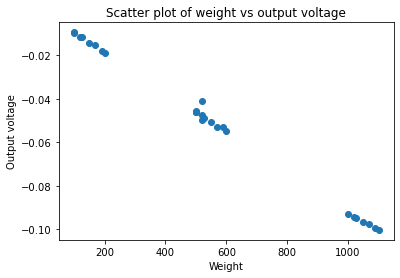

In [69]:
#Insert Solution
#1
plt.scatter(ForceCal.Weight, ForceCal.OutV)
plt.xlabel('Weight')
plt.ylabel('Output voltage')
plt.title('Scatter plot of weight vs output voltage')
plt.show()


# 2

It has a strong negative linear relation.


# 3

In [70]:
corr_matrix = ForceCal.corr()
print(corr_matrix)

             Weight   loadedV  unloadedV      OutV
Weight     1.000000 -0.949241   0.694944 -0.998896
loadedV   -0.949241  1.000000  -0.435541  0.959500
unloadedV  0.694944 -0.435541   1.000000 -0.671487
OutV      -0.998896  0.959500  -0.671487  1.000000


In [71]:
r = corr_matrix.loc['Weight', 'OutV']
r_squared = r**2
print(f"R-squared: {r_squared}")

R-squared: 0.9977927244670212


# 4

In [72]:
distmodel=np.polyfit(ForceCal.Weight,ForceCal.OutV,1)
print(distmodel)

[-9.15600105e-05 -9.61705675e-05]


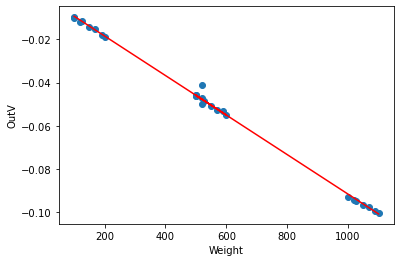

In [73]:
Distpred=np.poly1d(distmodel) # construct predicted output based on model

D_lin_reg=Distpred(ForceCal.Weight)
plt.scatter(ForceCal.Weight,ForceCal.OutV)
plt.plot(ForceCal.Weight,D_lin_reg, color='red')

plt.xlabel("Weight")
plt.ylabel('OutV')
plt.show()

# Additional task

$$OutV= a*Weight + b$$

$$Weight = \frac{OutV - b}{a}$$